# Step 3: Projection Model

Builds the per-player-per-week fantasy point projection model. Built up piece by piece, matching `ROADMAP.md` Step 3:
1. Multi-season raw data pull
2. Feature engineering (trailing form, season-to-date/prior-season, categorical)
3. Train/val/test split by season
4. Baseline model
5. LightGBM model
6. Evaluation (per position)


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from nflverse_loader import load_players, load_weekly_stats
from data_loader import normalize_player_week


🧒 **ELI5:** Imagine guessing how many goals a friend will score in their next soccer game. If you only ever watched **one** of their games, you couldn't tell if they're usually amazing or if that was just a lucky day. The more games you watch, the better your guess gets. That's this step — instead of 1 season, we gather **6 whole seasons** of every player's games so the computer has plenty of examples to learn the pattern from.


## 1. Multi-season raw data pull

2019-2024: recent enough that the modern passing-heavy game context still applies, enough volume for weekly-level training. Train 2019-2022, validate 2023, test 2024 (picked in piece 6).

Two real bugs surfaced and fixed while wiring this up (see `PROJECTS.md`/`ROADMAP.md` for detail): `PLAYERS_SCHEMA` was missing `season` (team/bye_week are season-dependent, not identity metadata — only worked before because every caller pulled one season at a time), and 2022's bye-week derivation double-counted the Week 17 Bills-Bengals game (suspended after Damar Hamlin's on-field cardiac arrest, never replayed) as a phantom bye for both teams.

In [2]:
SEASONS = list(range(2019, 2025))

players = load_players(SEASONS)
weekly = load_weekly_stats(SEASONS)
player_week = normalize_player_week(players, weekly)

print(f"players: {players.shape}, weekly: {weekly.shape}, player_week: {player_week.shape}")
player_week["season"].value_counts().sort_index()


players: (18576, 6), weekly: (39224, 14), player_week: (39224, 19)


season
2019    6165
2020    6354
2021    6702
2022    6653
2023    6640
2024    6710
Name: count, dtype: int64

In [3]:
# Sanity check: fantasy points by position, roughly matches expected scale
# (QB highest, then RB/WR, TE a bit lower, K always 0 — kicker scoring isn't
# wired into WEEKLY_STATS_SCHEMA yet, see schema.py).
player_week.groupby("position")["fantasy_points"].agg(["count", "mean"]).round(2)


,count,mean
position,,
DB,29,0.51
DL,1,0.00
K,3330,0.00
LB,9,0.11
P,15,0.00
QB,4065,14.02
RB,9397,8.00
TE,7280,5.63
WR,15098,7.61


🧒 **ELI5:** If you wanted to guess how many candies your friend will bring tomorrow, a great first guess is *"probably about how many they brought the last few days."* That's "trailing form" — looking at a player's last 3-5 games to guess their next one.

But there's one very important rule: **no peeking at the answer before you guess!** We're never allowed to use *this* week's actual score to help guess *this* week's score — that's like sneaking a look at the answer key. Every trailing average only looks **backward**, at games that already happened. That's what the picture below shows.


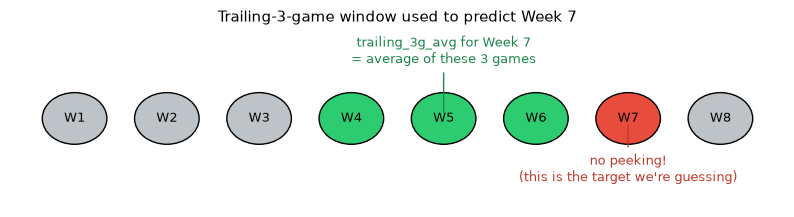

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.3))
current_week = 7
window = 3
for w in range(1, 9):
    if w == current_week:
        color, label = "#e74c3c", "predicting\nthis one"
    elif current_week - window <= w < current_week:
        color, label = "#2ecc71", "allowed to\nlook at"
    else:
        color, label = "#bdc3c7", None
    ax.add_patch(plt.Circle((w, 0), 0.35, color=color, ec="black", zorder=3))
    ax.text(w, 0, f"W{w}", ha="center", va="center", fontsize=9, zorder=4)

ax.annotate(
    "trailing_3g_avg for Week 7\n= average of these 3 games", xy=(5, 0.05), xytext=(5, 0.75),
    ha="center", fontsize=9, color="#1e8449",
    arrowprops=dict(arrowstyle="-", color="#1e8449", lw=1),
)
ax.annotate(
    "no peeking!\n(this is the target we're guessing)", xy=(current_week, -0.05), xytext=(current_week, -0.85),
    ha="center", fontsize=9, color="#c0392b",
    arrowprops=dict(arrowstyle="-", color="#c0392b", lw=1),
)
ax.set_xlim(0.3, 8.7)
ax.set_ylim(-1.2, 1.2)
ax.axis("off")
ax.set_title("Trailing-3-game window used to predict Week 7", fontsize=11)
plt.show()


## 2. Feature engineering: trailing form

Rolling averages of a player's own `fantasy_points`, computed causally (shifted so a given week's features never see that week's own result). Carries across season boundaries rather than resetting to NaN each September - a player's last 3 games are still the most relevant signal of current form.


In [5]:
from features import add_trailing_form_features

featured = add_trailing_form_features(player_week)
featured[["trailing_3g_avg", "trailing_5g_avg"]].describe()


,trailing_3g_avg,trailing_5g_avg
count,37916.000000,37916.000000
mean,7.468254,7.483758
std,6.749042,6.421094
min,-2.780000,-2.780000
25%,1.766667,2.120000
50%,5.833333,6.000000
75%,11.733333,11.740000
max,46.800000,46.800000


In [6]:
# Eyeball check against a real player's game log, including a season boundary
# and a real injury gap (McCaffrey missed 2024 weeks 1-9).
sample_id = "00-0033280"  # Christian McCaffrey
cols = ["name", "season", "week", "fantasy_points", "trailing_3g_avg", "trailing_5g_avg"]
featured.loc[featured["player_id"] == sample_id, cols].sort_values(["season", "week"]).tail(12)


,name,season,week,fantasy_points,trailing_3g_avg,trailing_5g_avg
30121,Christian McCaffrey,2023,13,22.3,24.133333,24.96
30435,Christian McCaffrey,2023,14,16.3,24.833333,24.90
30795,Christian McCaffrey,2023,15,41.7,23.166667,22.20
31180,Christian McCaffrey,2023,16,25.1,26.766667,26.50
31547,Christian McCaffrey,2023,17,13.1,27.700000,27.26
32367,Christian McCaffrey,2023,20,31.8,26.633333,23.70
32452,Christian McCaffrey,2023,21,29.2,23.333333,25.60
32493,Christian McCaffrey,2023,22,28.0,24.700000,28.18
35791,Christian McCaffrey,2024,10,16.7,29.666667,25.44
36121,Christian McCaffrey,2024,11,14.6,24.633333,23.76


🧒 **ELI5:** There are two different questions you could ask about a player:
- *"How have they been doing **this year** so far?"* (season-to-date)
- *"How did they do **last year** overall?"* (prior season)

Both matter! Early in a new season we haven't seen many games yet, so we lean on last year's performance as a backup — like asking *"well, how did you do on last year's spelling test?"* when this year's first test hasn't happened yet.


## 3. Feature engineering: season-to-date + prior-season

`season_to_date_avg` deliberately resets each season - a different question ("how is this player doing this year") than trailing form. `prior_season_*` covers the cold-start gap early in a season: a returning veteran's last full season is a much better prior than nothing for Week 1-3. True rookies still end up NaN (no prior season in this dataset at all) - left for LightGBM to handle natively.


In [7]:
from features import add_season_to_date_features, add_prior_season_features

featured = add_season_to_date_features(featured)
featured = add_prior_season_features(featured)
featured[["season_to_date_avg", "prior_season_total_points", "prior_season_avg_points"]].describe()


,season_to_date_avg,prior_season_total_points,prior_season_avg_points
count,35379.000000,26941.000000,26941.000000
mean,7.417576,110.484619,7.781264
std,6.456293,103.405082,6.105792
min,-2.860000,-2.880000,-2.880000
25%,1.950000,21.100000,2.633333
50%,5.975000,85.200000,6.807143
75%,11.746154,174.700000,12.142857
max,46.800000,554.800000,30.133333


In [8]:
# Verify against McCaffrey's real 2022 -> 2023 transition.
cols = ["name", "season", "week", "fantasy_points", "season_to_date_avg",
        "prior_season_total_points", "prior_season_avg_points"]
featured.loc[(featured["player_id"] == "00-0033280") & (featured["season"] == 2023), cols].head(5)


,name,season,week,fantasy_points,season_to_date_avg,prior_season_total_points,prior_season_avg_points
11804,Christian McCaffrey,2023,1,25.9,NaN,416.26,20.813
11805,Christian McCaffrey,2023,2,22.5,25.900000,416.26,20.813
11806,Christian McCaffrey,2023,3,22.9,24.200000,416.26,20.813
11807,Christian McCaffrey,2023,4,48.7,23.766667,416.26,20.813
11808,Christian McCaffrey,2023,5,13.8,30.000000,416.26,20.813


🧒 **ELI5:** Computers are great at math with numbers, but "quarterback" and "running back" aren't numbers — they're just labels. We tell the computer *"hey, these are different groups,"* and LightGBM is clever enough to learn a separate pattern for each group on its own — no need for us to invent secret numbers to stand in for each position.


## 4. Feature engineering: categorical/context

Position and team, cast to pandas `category` dtype so LightGBM can split on them natively (no one-hot encoding). A "bye-week flag" was in the original plan for this piece but got dropped: every row here already represents a game the player actually played (byes produce no stat line at all), so the flag could never be True on any real row.

`build_features()` now wraps all four pieces (trailing form, season-to-date, prior-season, categorical) into one call - used from here on instead of chaining the individual functions.


In [9]:
from features import build_features, FEATURE_COLUMNS

featured = build_features(player_week)
featured[["position", "team"]].dtypes


position    category
team        category
dtype: object

In [10]:
FEATURE_COLUMNS


['trailing_3g_avg',
 'trailing_5g_avg',
 'season_to_date_avg',
 'prior_season_total_points',
 'prior_season_games_played',
 'prior_season_avg_points',
 'position',
 'team']

🧒 **ELI5:** Think about studying for a big test:
- You study using homework and practice problems (**train**)
- You take a practice quiz to see how you're doing, and adjust your studying (**validate**)
- Then you take the **real test** — one you've genuinely never seen (**test**)

If you "practiced" using the exact real test questions, you'd get 100% — but that wouldn't prove you actually learned anything! That's why we split **by season**: train on old seasons, practice-quiz on 2023, and save 2024 as the untouched real test. Time only moves forward — the model never gets to peek at a season that, from its point of view, hasn't happened yet.


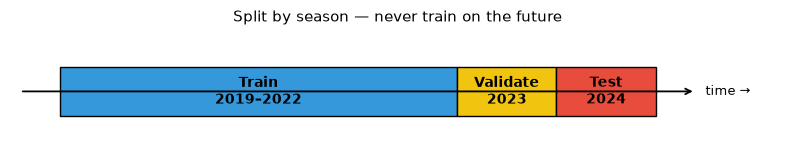

In [11]:
fig, ax = plt.subplots(figsize=(10, 1.6))
segments = [
    ("Train\n2019–2022", 2019, 2023, "#3498db"),
    ("Validate\n2023", 2023, 2024, "#f1c40f"),
    ("Test\n2024", 2024, 2025, "#e74c3c"),
]
for label, start, end, color in segments:
    ax.barh(0, end - start, left=start, color=color, edgecolor="black")
    ax.text((start + end) / 2, 0, label, ha="center", va="center", fontsize=10, fontweight="bold")
ax.annotate("", xy=(2025.4, 0), xytext=(2018.6, 0), arrowprops=dict(arrowstyle="->", lw=1.3))
ax.text(2025.5, 0, "time →", va="center", fontsize=9)
ax.set_xlim(2018.5, 2026.3)
ax.set_ylim(-1, 1)
ax.axis("off")
ax.set_title("Split by season — never train on the future", fontsize=11)
plt.show()


## 5. Train/val/test split

Scoped to QB/RB/WR/TE only: K's fantasy_points is a data gap pretending to be a real zero (kicker FG/PAT stats aren't wired into WEEKLY_STATS_SCHEMA yet), and the handful of DB/DL/LB/P rows are gadget-play noise, not standard fantasy production.

Split **by season**, not by row - train 2019-2022, validate 2023, test 2024 - so no future season ever leaks into training.


In [12]:
from projection_model import filter_to_model_positions, split_by_season

modelable = filter_to_model_positions(featured)
train, val, test = split_by_season(modelable, train_seasons=[2019, 2020, 2021, 2022], val_season=2023, test_season=2024)

print(f"train: {train.shape} ({sorted(train['season'].unique())})")
print(f"val:   {val.shape} ({sorted(val['season'].unique())})")
print(f"test:  {test.shape} ({sorted(test['season'].unique())})")


train: (23637, 25) ([np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)])
val:   (6065, 25) ([np.int64(2023)])
test:  (6138, 25) ([np.int64(2024)])


In [13]:
# Position mix should look similar across splits - no season should be skewing
# heavily toward one position (would suggest a filtering bug).
for name, split in [("train", train), ("val", val), ("test", test)]:
    print(name, dict(split["position"].value_counts()))


train {'WR': np.int64(9940), 'RB': np.int64(6262), 'TE': np.int64(4774), 'QB': np.int64(2661), 'DB': np.int64(0), 'DL': np.int64(0), 'K': np.int64(0), 'LB': np.int64(0), 'P': np.int64(0)}
val {'WR': np.int64(2599), 'RB': np.int64(1527), 'TE': np.int64(1232), 'QB': np.int64(707), 'DB': np.int64(0), 'DL': np.int64(0), 'K': np.int64(0), 'LB': np.int64(0), 'P': np.int64(0)}
test {'WR': np.int64(2559), 'RB': np.int64(1608), 'TE': np.int64(1274), 'QB': np.int64(697), 'DB': np.int64(0), 'DL': np.int64(0), 'K': np.int64(0), 'LB': np.int64(0), 'P': np.int64(0)}


🧒 **ELI5:** Before trusting a fancy robot to guess something, it's smart to first ask: *"could a really simple rule do almost as well?"* If a simple rule (like "guess about the same as their last 3 games") already does pretty well, the fancy robot better beat it, or it's not worth the extra complexity! This simple rule is called a **baseline** — the bar the real model has to clear.


## 6. Baseline model

The trailing-3-game average *is* the baseline prediction, with a cascading fallback for rows where it's NaN (a player's first tracked game, or first game of a season): trailing average -> prior-season average -> the position's overall training-set average (a true rookie's very first game has neither). The fallback average is fit from training data only. This is the bar LightGBM has to beat.


In [14]:
from sklearn.metrics import mean_absolute_error
from projection_model import fit_baseline, baseline_predict

position_fallback = fit_baseline(train)
val_baseline_pred = baseline_predict(val, position_fallback)

assert val_baseline_pred.isna().sum() == 0, "baseline should never be NaN after fallback"

print("Baseline MAE by position (validation, 2023):")
for pos in ["QB", "RB", "WR", "TE"]:
    mask = val["position"] == pos
    mae = mean_absolute_error(val.loc[mask, "fantasy_points"], val_baseline_pred[mask])
    print(f"  {pos}: {mae:.2f}")


Baseline MAE by position (validation, 2023):
  QB: 6.42
  RB: 4.73
  WR: 4.79
  TE: 3.82


🧒 **ELI5:** Imagine a team of students all guessing a player's score, one at a time. The first student makes a guess. The second student doesn't start over — they just look at what the *first* student got wrong and try to fix those specific mistakes. The third student fixes what's still wrong after student two, and so on. Add up everyone's guesses (and corrections) and you get a really good final answer. That's **gradient boosting** (what LightGBM does): it builds many small decision trees, one after another, each one fixing the mistakes of the ones before it.

But there's a trap: if you let the students keep "fixing mistakes" forever, they start memorizing tiny random details of the *practice* questions instead of the real pattern — like memorizing your practice quiz's exact wording instead of the concept it was testing. That's called **overfitting**. So after every new tree we check the practice-quiz (validation) score, and **stop adding trees** the moment that score stops improving — called **early stopping**. The chart below is real training data from this exact model (a diagnostic copy, not used for the real predictions below) showing exactly that pattern.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 23637, number of used features: 8
[LightGBM] [Info] Start training from score 8.138777


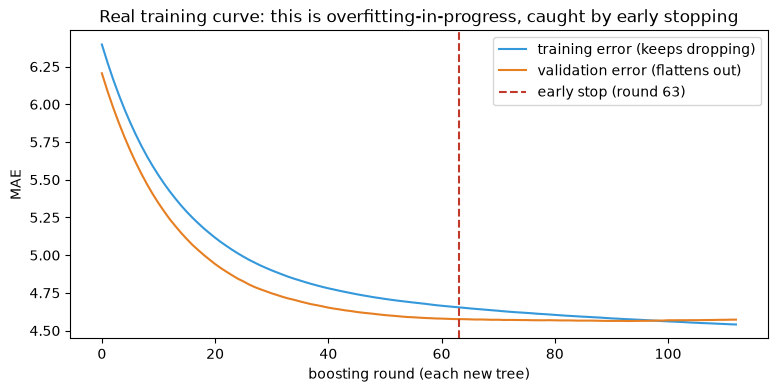

In [15]:
import lightgbm as lgb

# Diagnostic-only model: identical settings to the real `model` above, but also
# scored against the *training* set every round so we can plot both curves. Not
# used for any of the real predictions/evaluation elsewhere in this notebook.
diagnostic_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
diagnostic_model.fit(
    train[FEATURE_COLUMNS], train["fantasy_points"],
    eval_X=(train[FEATURE_COLUMNS], val[FEATURE_COLUMNS]),
    eval_y=(train["fantasy_points"], val["fantasy_points"]),
    eval_names=["train", "validation"],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

train_curve = diagnostic_model.evals_result_["train"]["l1"]
val_curve = diagnostic_model.evals_result_["validation"]["l1"]
stop_at = diagnostic_model.best_iteration_

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_curve, label="training error (keeps dropping)", color="#3498db")
ax.plot(val_curve, label="validation error (flattens out)", color="#e67e22")
ax.axvline(stop_at, color="#c0392b", linestyle="--", label=f"early stop (round {stop_at})")
ax.set_xlabel("boosting round (each new tree)")
ax.set_ylabel("MAE")
ax.set_title("Real training curve: this is overfitting-in-progress, caught by early stopping")
ax.legend()
plt.show()


## 7. LightGBM model

Early-stops against the validation set (2023) to pick the number of trees - the held-out test set (2024) stays completely untouched until the final evaluation in the next section.


In [16]:
from projection_model import train_lightgbm

model = train_lightgbm(train, val)
print(f"best iteration: {model.best_iteration_}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 23637, number of used features: 8
[LightGBM] [Info] Start training from score 8.138777


best iteration: 63


In [17]:
# Quick sanity check on validation (the set it was early-stopped against,
# not a clean holdout - the real comparison against baseline happens on
# the untouched test set next).
val_model_pred = model.predict(val[FEATURE_COLUMNS])
print("LightGBM MAE by position (validation, 2023):")
for pos in ["QB", "RB", "WR", "TE"]:
    mask = (val["position"] == pos).to_numpy()
    mae = mean_absolute_error(val.loc[mask, "fantasy_points"], val_model_pred[mask])
    print(f"  {pos}: {mae:.2f}")


LightGBM MAE by position (validation, 2023):
  QB: 6.07
  RB: 4.58
  WR: 4.62
  TE: 3.63


🧒 **ELI5:** Now for the real test — 2024 data, never seen before. We check *"how wrong was each guess, on average?"* using two different rulers:
- **MAE** (Mean Absolute Error): on average, how many points off were we? Simple and fair.
- **RMSE** (Root Mean Squared Error): similar, but it punishes *big* misses much harder than small ones — like a game where being off by 1 point costs you $1, but being off by 10 points costs you $100, not just $10.

The toy example below is computed for real (not made up): two error patterns with the *exact same* MAE, but very different RMSE, because one of them hides a single big blowup miss.


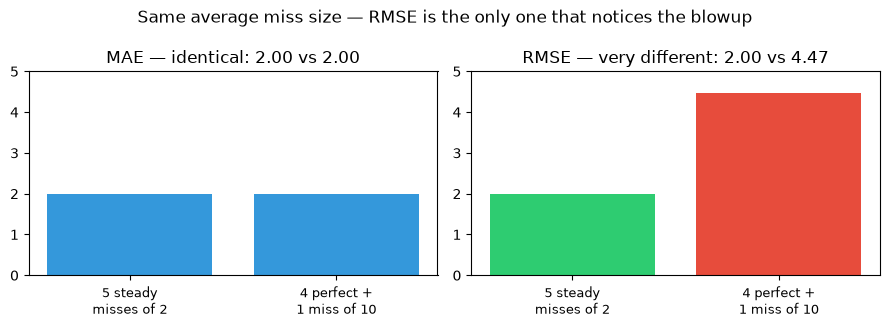

In [18]:
import numpy as np

steady_misses = np.array([2, 2, 2, 2, 2])       # five small, consistent misses
one_big_miss = np.array([0, 0, 0, 0, 10])       # four perfect guesses, one huge miss

mae_steady = np.mean(np.abs(steady_misses))
mae_big = np.mean(np.abs(one_big_miss))
rmse_steady = np.sqrt(np.mean(steady_misses ** 2))
rmse_big = np.sqrt(np.mean(one_big_miss ** 2))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
labels = ["5 steady\nmisses of 2", "4 perfect +\n1 miss of 10"]
x = np.arange(2)

axes[0].bar(x, [mae_steady, mae_big], color="#3498db")
axes[0].set_title(f"MAE — identical: {mae_steady:.2f} vs {mae_big:.2f}")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=9); axes[0].set_ylim(0, 5)

axes[1].bar(x, [rmse_steady, rmse_big], color=["#2ecc71", "#e74c3c"])
axes[1].set_title(f"RMSE — very different: {rmse_steady:.2f} vs {rmse_big:.2f}")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=9); axes[1].set_ylim(0, 5)

fig.suptitle("Same average miss size — RMSE is the only one that notices the blowup")
fig.tight_layout()
plt.show()


## 8. Final evaluation (held-out test set, 2024)

The real comparison. 2024 was never touched during training or early stopping - this is the first time either model sees it.


In [19]:
from projection_model import evaluate_by_position

test_baseline_pred = baseline_predict(test, position_fallback)
test_model_pred = model.predict(test[FEATURE_COLUMNS])

baseline_eval = evaluate_by_position(test["fantasy_points"], test_baseline_pred, test["position"])
model_eval = evaluate_by_position(test["fantasy_points"], pd.Series(test_model_pred, index=test.index), test["position"])

comparison = baseline_eval[["mae", "rmse"]].join(
    model_eval[["mae", "rmse"]], lsuffix="_baseline", rsuffix="_lightgbm"
)
comparison["mae_improvement_pct"] = (
    (comparison["mae_baseline"] - comparison["mae_lightgbm"]) / comparison["mae_baseline"] * 100
)
comparison.round(2)


,mae_baseline,rmse_baseline,mae_lightgbm,rmse_lightgbm,mae_improvement_pct
position,,,,,
QB,6.57,8.42,6.33,7.89,3.65
RB,4.64,6.45,4.55,6.11,1.85
WR,4.89,6.85,4.68,6.33,4.35
TE,3.85,5.39,3.73,4.95,3.31


🧒 **ELI5:** This chart is the easiest way to "eyeball" how good the model is. Each dot is one real player-week. The red dashed line is *perfect* — if a guess exactly matched reality, the dot would sit right on that line. Dots close to the line = good guesses. Dots far above or below = the model over- or under-guessed that week.


## 9. Visualize: projected vs. actual


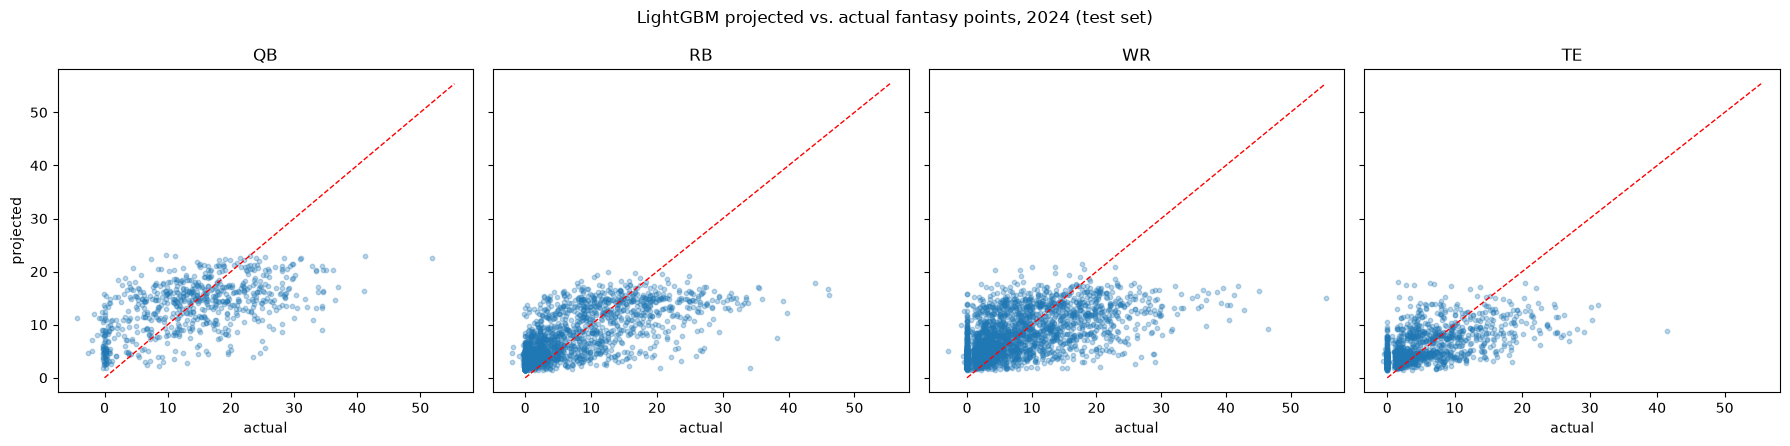

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, pos in zip(axes, ["QB", "RB", "WR", "TE"]):
    mask = test["position"] == pos
    ax.scatter(test.loc[mask, "fantasy_points"], test_model_pred[mask.to_numpy()], alpha=0.3, s=10)
    lims = [0, test["fantasy_points"].max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(pos)
    ax.set_xlabel("actual")
axes[0].set_ylabel("projected")
fig.suptitle("LightGBM projected vs. actual fantasy points, 2024 (test set)")
fig.tight_layout()
